In [ ]:
# my thinking process:
# we need narrow the scope to find useful information
# check all the category of grammy_winner.csv, check the word 'rock',there are so many category in one type of song. I choose the representative category -- record of the year  / song of the year
# In spotify, there are some different songs with same name. So we need both use the artist_name and song_name to match them.
# In grammy, there are 500 rows every year. both winner and nominee records 5 per year.
# song of the year 5  record of the year 5
# focus on random year 2000 and 2001, there are some record in song of the year category not have artist_name. I find another dataset https://www.kaggle.com/datasets/kfoster150/grammy-award-nominees-and-winners-1958-2024?select=Grammy+Award+Nominees+and+Winners+1958-2024.csv this dataset is more accurate.
# I find in 2002, artist of the song Don't know why in record of the year is Norah Jones, but in song of the year, the name is behind others. artist name like this: Jesse Harris, songwriter (Norah Jones)
# This the grammy official link https://www.grammy.com/awards/45th-annual-grammy-awards
# However, in record of songs , there always show the main artist name separate with their producer team.
# Another sample,in 2003,the song love yourself in record of the year that artist is Eminem, in song of the year, artist is Jeff Bass, Eminem & L Resto, songwriters (Eminem). This situation is hard to deal with.
#So in final, I decide focus on record of the year, this category are most representative. And data are relative clean to handle in order to match with spotify dataset.

# in this file, the final result is grammy_group.csv, it includes 130 records from 2000 to 2023.
# this subset is  merged from grammy and spotify, and belongs to the grammy group, are all the year songs in grammy.
# we can use it compare with the most popular topn songs in spotify every year to show a story base on the song feature in spotify.
# we can compare with whole period's trend, or we just focus on every year's grammy songs and most popular songs, to tell another story, which songs are win in both grammy critics and spotify audiences?

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
grammy=pd.read_csv("../Data/grammy_winners.csv")
spotify=pd.read_csv("../Data/spotify_data.csv")
print(len(grammy))
print(len(spotify))

25370
1159764


In [ ]:
grammy.columns

Index(['year', 'annual_edition', 'category', 'artist', 'producers',
       'song_or_album', 'winner', 'url'],
      dtype='object')

In [ ]:
#spotify.head()

In [ ]:
#grammy.head()

In [ ]:
grammy['category'].value_counts().head(10)

category
Song Of The Year                  364
Record Of The Year                362
Album Of The Year                 348
Best Opera Recording              334
Best Album Notes                  315
Best Country Song                 274
Best New Artist                   268
Best Instrumental Composition     261
Best Chamber Music Performance    243
Best Historical Album             218
Name: count, dtype: int64

In [ ]:
# filter year [2000,2023] and category == 'Record Of The Year'
mask1= grammy['year'].between(2000,2023)
mask2= grammy['category']=='Record Of The Year'
filtered_grammy=grammy[mask1 & mask2]

In [ ]:
# add index column, keep origin_index in order to location the record
filtered_grammy['origin_index']=filtered_grammy.index
#filtered_grammy.head()

In [ ]:
# check missing value
count=filtered_grammy['song_or_album'].isna().sum()
print(f'nan value of sont_or_album count:{count}')

nan value of sont_or_album count:0


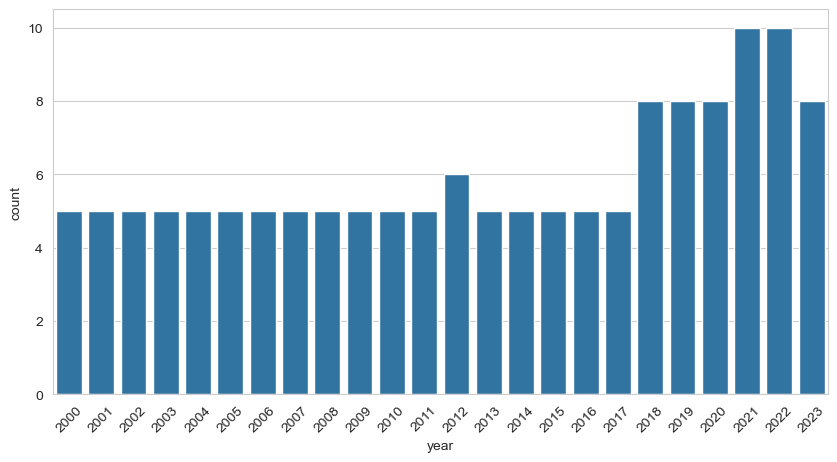

In [ ]:
# show each year count, most of them are 5
vc=filtered_grammy['year'].value_counts()
plt.figure(figsize=(10,5))
sns.barplot(data=vc)
plt.xticks(rotation=45)
plt.show()

In [ ]:
# handel the column song_or_album, delete blank,and cut brackets that after the song name
# like this xxx (single),xxx (track)
filtered_grammy['song_or_album']=filtered_grammy['song_or_album'].str.replace(r'\s*\(.+\)$', '', regex=True).str.strip()

In [ ]:
# focus on the 143 records
len(filtered_grammy)
# grammy.to_csv('../Data/filter_grammy.csv',index=False)

143

In [ ]:
#filtered_grammy.head()

In [ ]:
#spotify.head()

In [ ]:
# preparation before merge data: change to lower case
spotify_lower=spotify.copy()
filtered_grammy_lower=filtered_grammy.copy()
filtered_grammy_lower['artist']=filtered_grammy_lower['artist'].str.lower()
filtered_grammy_lower['song_or_album']=filtered_grammy_lower['song_or_album'].str.lower()
spotify_lower['artist_name']=spotify_lower['artist_name'].str.lower()
spotify_lower['track_name']=spotify_lower['track_name'].str.lower()

In [ ]:
# use artist_name and track_name from spotify to inner merge artist and song_or_album from grammy
# only 90 record can directly match, keep these data(merged_inner)
merged_inner = pd.merge(
    spotify_lower,
    filtered_grammy_lower,
    left_on=['artist_name', 'track_name'],
    right_on=['artist', 'song_or_album'],
    how='inner',   # optional：'inner' / 'left' / 'right' / 'outer'
    indicator=True
)
len(merged_inner)

90

In [ ]:
# use right merge to get the data that unmatch
merged_right = pd.merge(
    spotify_lower,
    filtered_grammy_lower,
    left_on=['artist_name', 'track_name'],
    right_on=['artist', 'song_or_album'],
    how='right',
    indicator=True
)

In [ ]:
# get 54 unmatched data,restore the origin_index after merge
un_match= merged_right[merged_right['_merge'] =='right_only']

un_match.set_index('origin_index', inplace=True)
# un_match.head()
len(un_match)

54

In [ ]:
# a simple experiment: try to do the contains match, not equal match
# but it is not useful, first: only 20 rows be matched, second: these record only has the data from spotify, not contains grammy, we still need to conbine them.
artist_pattern= '|'.join(un_match['artist'])
track_pattern= '|'.join(un_match['song_or_album'])

mask1=spotify_lower['artist_name'].str.contains(artist_pattern,case=False,na=False)
mask2=spotify_lower['track_name'].str.contains(track_pattern,case=False,na=False)

matched= spotify_lower[mask1 & mask2]
len(matched)

20

In [ ]:
# create the temp data file.
# matched.to_csv(f'../Data/vague_matched_{len(matched)}.csv',index=False)

# I will try to match them by hand, because sometimes it's hard to match with two string columns.
# create the temp file, to check which song are not match.
un_match_csv=un_match[['artist','song_or_album','url']]
un_match_csv.to_csv(f'../Data/un_match_{len(un_match)}.csv')

In [ ]:
'''
this is my manual processing:
I found that one songs have several different versions and they have different popularity score
I found that some artist_name in grammy format like this : Doja Cat Featuring SZA
I found that some song_or_album in spotify format like this: kiss me more (feat. sza)
And there are some different we can't find the Pattern like this: grammy Lady Antebellum in grammy, Lady A in spotify;
there are two peoples belongs to a song in grammy,but in spotify,there are separated. like: Jay-Z & Alicia Keys
and other sample :
cee lo green -> CeeLo Green
The Black Eyed Peas -> Black Eyed Peas
Dixie Chicks -> the chicks
N Sync -> *NSYNC


below are manual work：


961,Jon Batiste,Worship  | no one
963,Billie Eilish,What Was I Made For? [From The Motion Picture Barbie] | no one 2023年的不知道有没
964,Victoria Monét,On My Mama                               | no one
981,Olivia Rodrigo,vampire                                  | no one
997,Steve Lacy,Bad Habit                                    | no one
999,Brandi Carlile Featuring Lucius,You And Me On The Rock  | 495913	brandi carlile	you and me on the rock (feat. lucius)	62
1883,Lil Nas X,Montero                                      | 506706	lil nas x	montero (call me by your name)	79
1886,Brandi Carlile,Right On Time  ✅
1887,Justin Bieber Featuring Daniel Caesar & Giveon,Peaches | 515584	justin bieber	peaches (feat. daniel caesar & giveon)	82
1888,Tony Bennett & Lady Gaga,I Get A Kick Out Of You       | 510000	tony bennett	i get a kick out of you	50
1889,Jon Batiste,Freedom                                    | no one
1907,Doja Cat Featuring SZA,Kiss Me More                    | 487896	doja cat	kiss me more (feat. sza)	80
1910,Silk Sonic,Leave The Door Open                        | no one
1945,Billie Eilish,Everything I Wanted ✅
2340,Post Malone,Circles                                  | no one
2341,Megan Thee Stallion Featuring Beyoncé,Savage         | 433259	megan thee stallion	savage remix (feat. beyoncé)	64
2343,DaBaby Featuring Roddy Ricch,Rockstar               | 452829	dababy	rockstar (feat. roddy ricch)	77
2357,Beyoncé,Black Parade ✅
2770,Lil Nas X Featuring Billy Ray Cyrus,Old Town Road   | 397305	lil nas x	old town road	75
2772,Post Malone & Swae Lee,Sunflower                   ｜no one
2789,Billie Eilish,Bad Guy ✅
3180,Lady Gaga & Bradley Cooper,Shallow                 | 321016	lady gaga	shallow	83
3216,Kendrick Lamar & SZA,All The Stars                 | 340887	kendrick lamar	all the stars (with sza)	83
3217,"Cardi B, Bad Bunny & J Balvin",I Like It          | 321021	cardi b	i like it	77
3239,Post Malone Featuring 21 Savage,Rockstar           | No one
3240,"Zedd, Maren Morris & Grey",The Middle            | 321017	zedd	the middle	78
3270,JAY-Z,The Story Of O.J. ✅
3271,Luis Fonsi & Daddy Yankee Featuring Justin Bieber,Despacito | 406412	luis fonsi	despacito	78
3668,Rihanna Featuring Drake,Work                       | No one
3669,Lukas Graham,7 Years                              | No one
4474,Mark Ronson Featuring Bruno Mars,Uptown Funk     | 197524	mark ronson	uptown funk (feat. bruno mars)	81
4497,D'Angelo And The Vanguard,Really Love            | 130176	d'angelo	really love	53
4498,Ed Sheeran,Thinking Out Loud ✅
4536,Iggy Azalea Featuring Charli XCX,Fancy             | 119695	iggy azalea	fancy	67
5266,Daft Punk Featuring Pharrell Williams & Nile Rodgers,Get Lucky | 72864	daft punk	get lucky (feat. pharrell williams & nile rodg...	80
5267,Robin Thicke Featuring T.I. & Pharrell,Blurred Lines | 66281	robin thicke	blurred lines	74
5268,Bruno Mars,Locked Out Of Heaven ✅
5358,Gotye Featuring Kimbra,Somebody That I Used To Know | 1147443	gotye	somebody that i used to know	74
5730,Kelly Clarkson,Stronger                         | 12363	kelly clarkson	stronger (what doesn't kill you)	40
5731,Fun. Featuring Janelle Monáe,We Are Young       | 40348 fun.	we are young (feat. janelle monáe)	72
5843,Adele,Rolling In The Deep ✅
6156,B.o.B Featuring Bruno Mars,Nothin' On You       | 1076535	b.o.b	nothin' on you (feat. bruno mars)	74
6171,Eminem Featuring Rihanna,Love The Way You Lie   | 1094145	eminem	love the way you lie	82
6172,Cee Lo Green,Fuck You                           | 1094153	ceelo green	fuck you	65
6173,Jay-Z & Alicia Keys,Empire State Of Mind        | 1047470	jay-z	empire state of mind	81 两个人的都有第二个人有第二个版本
6174,Lady Antebellum,Need You Now                    | 264766	lady a	need you now	25
7195,The Black Eyed Peas,I Gotta Feeling             | 591164	black eyed peas	i gotta feeling	0 ？265310 38分
7197,Kings Of Leon,Use Somebody                    ✅
7768,M.I.A,Paper Planes                              | 935552	m.i.a.	paper planes	75
7769,Robert Plant & Alison Krauss,Please Read The Letter | 930144	robert plant	please read the letter	39
7773,Justin Timberlake,What Goes Around…Comes Around |889695	justin timberlake	what goes around.../...comes around (interlude)	70
7795,Rihanna Featuring Jay-Z,Umbrella                | 960210	rihanna	umbrella	72
8373,Dixie Chicks,Not Ready To Make Nice             | 888932	the chicks	not ready to make nice	60
8896,Green Day,Boulevard Of Broken Dreams          ✅| 296629	green day	boulevard of broken dreams	75
8897,Kanye West,Gold Digger                          | No one
8899,Gorillaz Featuring De La Soul,Feel Good Inc.    | 862134	gorillaz	feel good inc.	82
9898,The Black Eyed Peas,Let's Get It Started        | 433343	black eyed peas	let's get it started	53
9901,Usher Featuring Lil Jon & Ludacris,Yeah!        | 801524	usher	yeah! (feat. lil jon & ludacris)	81
9902,Ray Charles & Norah Jones,Here We Go Again      | 481739	ray charles	here we go again	24
10161,OutKast,Hey Ya!                              ✅| 189160	outkast	hey ya!	48
10163,The Black Eyed Peas & Justin Timberlake,Where Is The Love | 759123	black eyed peas	where is the love?	78
10175,Beyoncé Featuring Jay-Z,Crazy In Love          | 759122	beyoncé	crazy in love (feat. jay-z)
10605,Nelly Featuring Kelly Rowland,Dilemma          | 605428	nelly	dilemma
11037,OutKast,Ms. Jackson                          ✅|645971	outkast	ms. jackson
11471,Train,Drops Of Jupiter                         | 674719	train	drops of jupiter (tell me)
11788,N Sync,Bye Bye Bye                             | 120390	*nsync	bye bye bye


11 not found

# the correlation index from both dataset.
{999:495913,1883:506706,1887:515584,1888:510000,1907:487896, 2341:433259,2343:452829,2770:397305,3180:321016,3216:340887,3217:321021,3240:321017,3271:406412,4474:197524,4497:130176,4536:119695,5266:72864,5267:66281,5358:1147443,5730:12363,5731:40348,6156:1076535,6171:1094145,6172:1094153,6173:1047470,6174:264766,7195:591164,7768:935552,7769:930144,7773:889695,7795:960210,8373:888932,8899:862134,9898:433343,9901:801524,9902:481739,10163:759123,10175:759122,10605:605428,11471:674719,11788:120390}
'''
#
# lower='We Are Young'.lower()
# temp=spotify_lower[['artist_name','track_name','popularity']]
#
# x=temp[temp['track_name'].str.contains(lower,na=False)].sort_values('popularity',ascending=False)
# # x=temp[temp['track_name']==lower].sort_values('popularity',ascending=False)
#
# # x=temp[temp['track_name'].str.contains(lower,na=False) & temp['artist_name'].str.contains('Olivia'.lower(),na=False)].sort_values('popularity',ascending=False)
# y=temp[temp['artist_name'].str.contains('Billie Eilish'.lower(),na=False)]
#
# x
#
# # with pd.option_context('display.max_rows', None, 'display.max_columns', None):
# #     print(x)



In [ ]:
# try to concat the manual result between two dataset
print(spotify_lower.shape)
print(filtered_grammy_lower.shape)


(1159764, 20)
(143, 9)


In [ ]:
# spotify_lower.columns
# fix the column name
spotify_lower_addindex = spotify_lower.rename(columns={'Unnamed: 0': 'spotify_index'})

In [ ]:
dict = {999:495913,1883:506706,1887:515584,1888:510000,1907:487896, 2341:433259,2343:452829,2770:397305,3180:321016,3216:340887,3217:321021,3240:321017,3271:406412,4474:197524,4497:130176,4536:119695,5266:72864,5267:66281,5358:1147443,5730:12363,5731:40348,6156:1076535,6171:1094145,6172:1094153,6173:1047470,6174:264766,7195:591164,7768:935552,7769:930144,7773:889695,7795:960210,8373:888932,8899:862134,9898:433343,9901:801524,9902:481739,10163:759123,10175:759122,10605:605428,11471:674719,11788:120390}


# get list from two dataset
grammy_part=filtered_grammy_lower.loc[dict.keys()].reset_index(drop=True)
spotify_part=spotify_lower_addindex.loc[dict.values()].reset_index(drop=True)

In [ ]:
# change column name to avoid conflict name
grammy_part.columns=['grammy_year', 'annual_edition', 'category', 'artist', 'producers',
       'song_or_album', 'winner', 'url', 'grammy_index']
# fix the column order
grammy_part=grammy_part[['grammy_index','grammy_year', 'annual_edition', 'category', 'artist', 'producers',
       'song_or_album', 'winner', 'url']]

In [ ]:
spotify_part.columns
#change column name :year -> spotify-year
spotify_part.columns=['spotify_index', 'artist_name', 'track_name', 'track_id', 'popularity',
       'spotify_year', 'genre', 'danceability', 'energy', 'key', 'loudness', 'mode',
       'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'duration_ms', 'time_signature']

In [ ]:
# horizontal concat two part
merged_2 = pd.concat([grammy_part, spotify_part], axis=1)

In [ ]:
# fix  merge inner column name  to adopt with merged_2
merged_inner_changename=merged_inner.rename(columns={'Unnamed: 0': 'spotify_index','year_x':'spotify_year','year_y':'grammy_year','origin_index':'grammy_index'})
merged_inner_changename.drop(columns=['_merge'], inplace=True)
merged_inner_changename.columns

Index(['spotify_index', 'artist_name', 'track_name', 'track_id', 'popularity',
       'spotify_year', 'genre', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'duration_ms', 'time_signature', 'grammy_year',
       'annual_edition', 'category', 'artist', 'producers', 'song_or_album',
       'winner', 'url', 'grammy_index'],
      dtype='object')

In [ ]:
merged_2.columns

Index(['grammy_index', 'grammy_year', 'annual_edition', 'category', 'artist',
       'producers', 'song_or_album', 'winner', 'url', 'spotify_index',
       'artist_name', 'track_name', 'track_id', 'popularity', 'spotify_year',
       'genre', 'danceability', 'energy', 'key', 'loudness', 'mode',
       'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'duration_ms', 'time_signature'],
      dtype='object')

In [ ]:
len(merged_2)

41

In [ ]:
len(merged_inner_changename)

90

In [ ]:
# vertical concat merged_2 and merged_inner get the  grammy_group result
result = pd.concat([merged_2,merged_inner_changename])

In [ ]:
# do some experiment
result[['grammy_index','spotify_index','grammy_year','spotify_year','artist','artist_name','song_or_album','track_name','popularity',]]

# find a duplicate record, deal with it
result['song_or_album'].value_counts()
# analyze with duplicate record
result[result['song_or_album']=='locked out of heaven'][['grammy_index','spotify_index','grammy_year','spotify_year','artist','artist_name','song_or_album','track_name','popularity']]

# delete the record that index is 61
result.drop(index=61,inplace=True)

In [ ]:
# create the result file
result.to_csv('../Data/grammy_group.csv', index=False)

In [ ]:
#filtered_grammy_lower.loc[5268]
#spotify.loc[[12104,591102]]
# result['song_or_album'].value_counts().head(1)
# len(result)
# result.nunique()